In [1]:
import numpy as np
import pandas as pd
import warnings
import h5py
import glob
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from multiprocessing import Pool
import time
import noctiluca as nl
from tqdm import tqdm

from polychrom.hdf5_format import HDF5Reporter, list_URIs, load_URI, load_hdf5_file, save_hdf5_file
from polychrom.polymer_analyses import contact_scaling, calculate_contacts
from polychrom.contactmaps import binnedContactMap, monomerResolutionContactMapSubchains
from polychrom.polymer_analyses import calculate_contacts

from scipy.optimize import minimize
from scipy.interpolate import CubicSpline, interp1d
from scipy.ndimage import grey_dilation
from scipy.optimize import curve_fit

from matplotlib import rcParams
plt.rcParams['font.family'] = 'Arial'
%config InlineBackend.figure_format='retina'


/home/jjusuf/miniconda3/envs/polysim/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


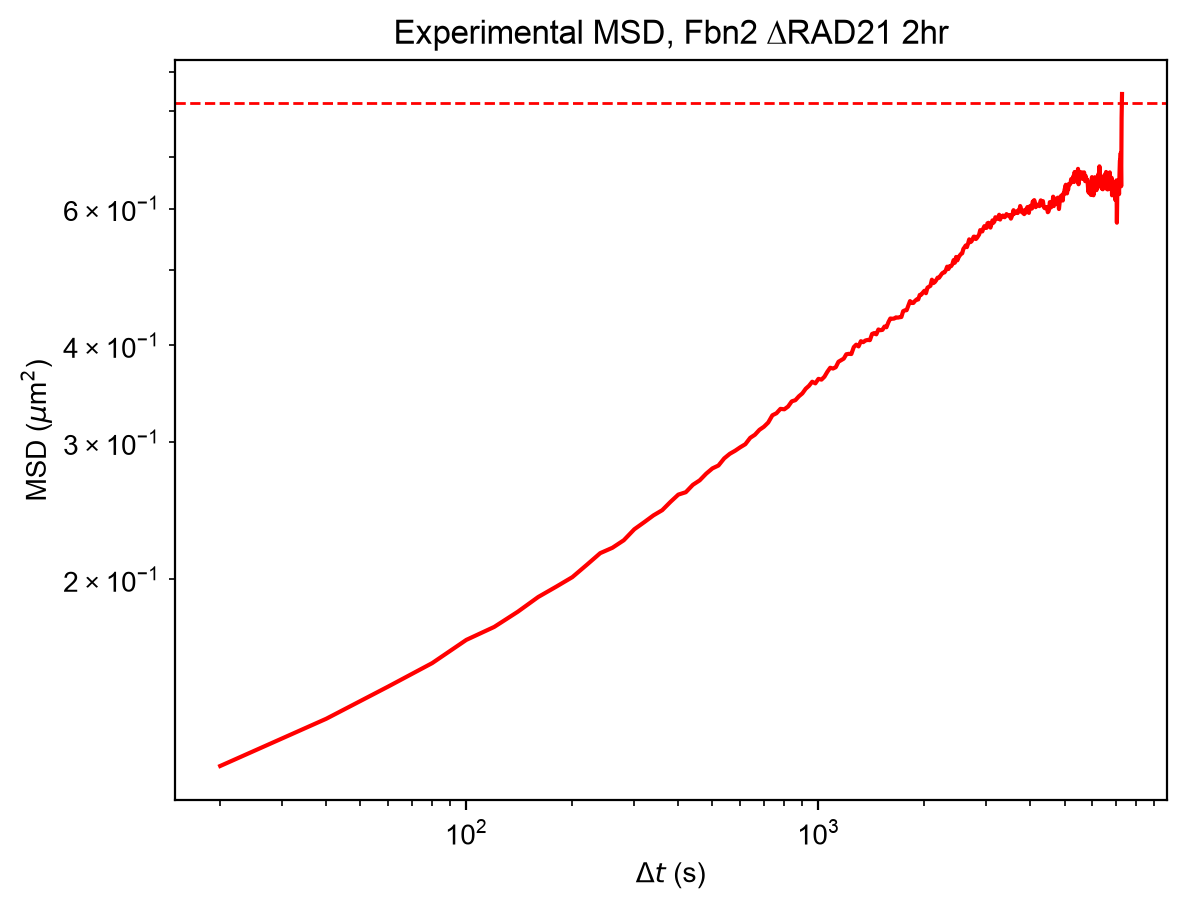

In [2]:
# Load Simon's data
file = '/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/2022_Fbn2_full_data.h5'

data = nl.io.load.hdf5(file, 'data')

# Calculate ΔRad21 MSD
data.makeSelection(['Rad21', '2hr'], logic=all)
msd = nl.analysis.MSD(data)

frame_duration = 20  # in seconds

# Plotting
delta_t_Fbn2 = np.arange(1, len(msd))*frame_duration
msd_Fbn2 = msd[1:]
plt.plot(delta_t_Fbn2, msd_Fbn2, color='red')
plt.axhline(y=0.82, linestyle='--', color='red', linewidth=1, zorder=-1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\Delta t$ (s)')
plt.ylabel(r'MSD ($\mu$m$^2$)')
plt.title('Experimental MSD, Fbn2 ∆RAD21 2hr')
plt.show()

In [ ]:
# load my data
files_no_LE_no_EP = list_URIs('/mnt/md1/jjusuf/looping_review/simulation_data_raw/sim_20260113_no_LE_no_EP')
print(f'-LE -EP: found {len(files_no_LE_no_EP)} blocks')


-LE -EP: found 97000 blocks


In [21]:
# test for chain equilibration

block_start = 0
block_end = 10_000
bin_step = 1000
block_step = 200

bin_edges = np.arange(block_start, block_end, bin_step)
print(f'{len(bin_edges)-1} bins along time axis')

contact_scalings = []
for i in tqdm(range(len(bin_edges)-1)):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    blocks_to_sample = np.arange(bin_start, bin_end, block_step)
    for j, block_num in enumerate(blocks_to_sample):
        uri = load_URI(files_no_LE_no_EP[block_num])
        block_data = uri['pos']
        if j == 0:
            cs_bins, num_contacts = contact_scaling(block_data, cutoff=2)
            scaling = num_contacts
        else:
            cs_bins, num_contacts = contact_scaling(block_data, cutoff=2)
            scaling += num_contacts
    contact_scalings.append(scaling)


9 bins along time axis


100%|██████████| 9/9 [00:03<00:00,  2.47it/s]


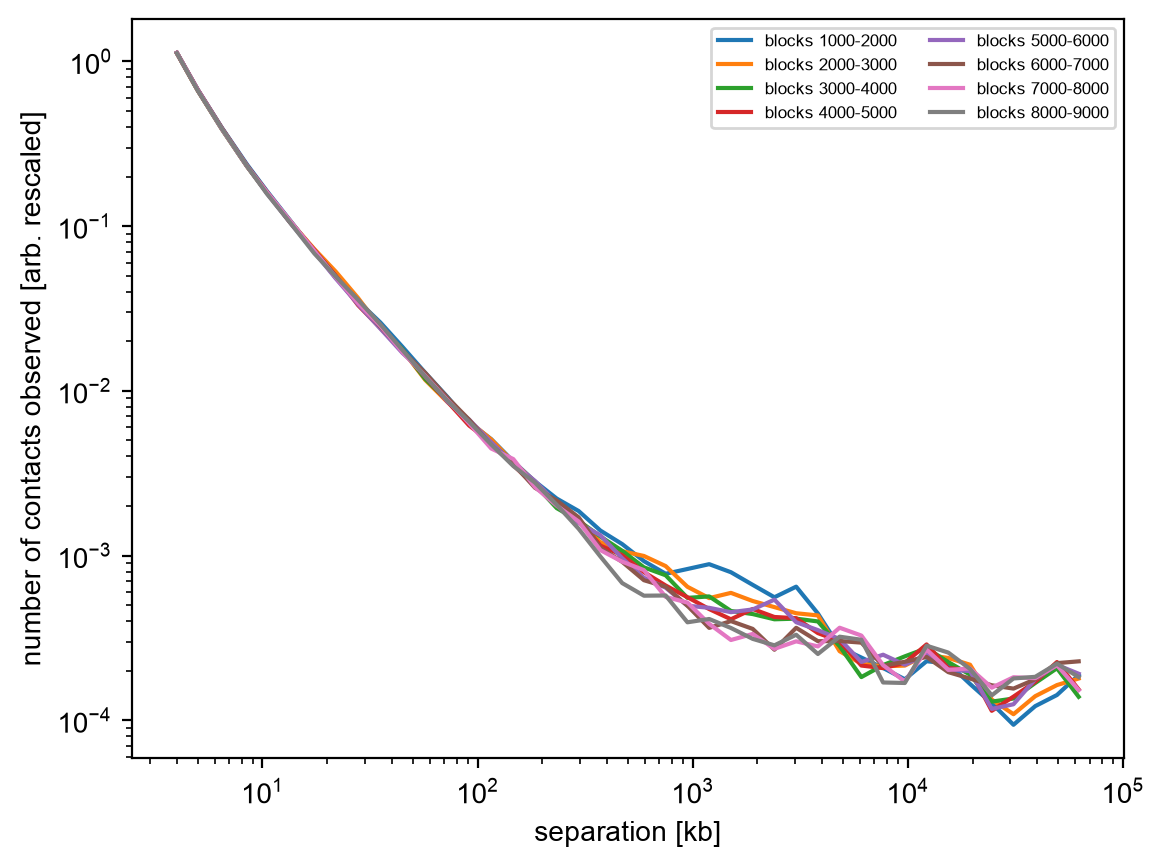

In [5]:
bin_strings = []
for i in range(len(bin_edges)-1):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    bin_string = f'blocks {bin_start}-{bin_end}'
    bin_strings.append(bin_string)
    plt.plot(cs_bins, contact_scalings[i])
plt.legend(bin_strings, fontsize=6, ncol=2)
plt.xscale('log')
plt.yscale('log');
plt.xlabel('separation [kb]')
plt.ylabel('number of contacts observed [arb. rescaled]');


100%|██████████| 194/194 [00:01<00:00, 180.98it/s]


1809.4198116768816


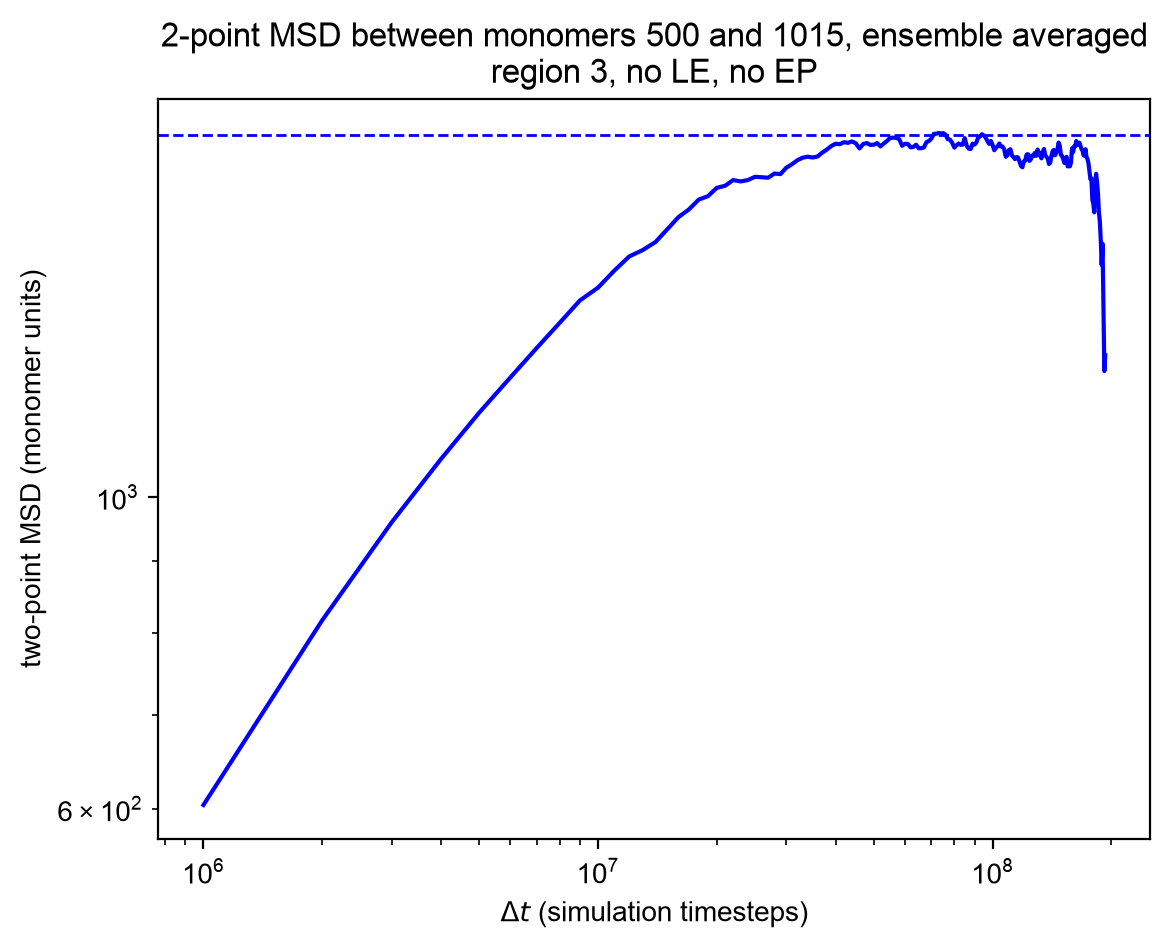

In [23]:
# define region, calculate my MSDs

region_size = 2000
num_chroms = 1
chrom_size = 70000
num_regions = chrom_size // region_size
region_starts = np.arange(num_regions) * region_size

block_start = 0
block_end = 97000
block_step = 500

pos1 = 500
pos2 = 1015

files_to_use = files_no_LE_no_EP
timesteps_per_block = 2000  # how many simulation timesteps per save block (from the simulation code)

blocks_to_sample = np.arange(block_start, block_end, block_step)
disp_vectors = np.zeros((len(blocks_to_sample), num_regions, 3))
for i, block_num in enumerate(tqdm(blocks_to_sample)):
    uri = load_URI(files_to_use[block_num])
    block_data = uri['pos']  # use the one with no LE or EP
    disp_vectors[i,:,:] = block_data[region_starts+pos2]-block_data[region_starts+pos1]

convergent_value = 2*np.square(disp_vectors).sum(2).mean()  # 2*<R^2>, the value that the MSD should converge to
print(convergent_value)

msd_df = pd.DataFrame(columns=['delta_t','msd'])
for i, offset in enumerate(np.arange(1, (block_end-block_start)//block_step)):
    msd = np.square(disp_vectors[offset:,:,:]-disp_vectors[:-offset,:,:]).sum(2).mean()
    msd_df.loc[i, 'delta_t'] = offset * block_step * timesteps_per_block
    msd_df.loc[i, 'msd'] = msd

fig, ax = plt.subplots()
ax.plot(msd_df['delta_t'], msd_df['msd'], color='blue')
ax.axhline(y=convergent_value, linestyle='--', color='blue', linewidth=1, zorder=-1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\Delta t$ (simulation timesteps)')
ax.set_ylabel('two-point MSD (monomer units)');
ax.set_title(f'2-point MSD between monomers {pos1} and {pos2}, ensemble averaged\nregion 3, no LE, no EP');


In [24]:
monomer_size_um = np.sqrt(0.82/convergent_value)  # best monomer size
print(monomer_size_um)

0.021288117350961203


In [25]:
def get_mse(monomer_size_um, sim_timestep_duration):

    delta_t_sim = msd_df['delta_t'] * sim_timestep_duration
    msd_sim = msd_df['msd'] * (monomer_size_um)**2
    
    y_func_real = interp1d(delta_t_Fbn2, msd_Fbn2)
    x_min_real = np.min(delta_t_Fbn2)
    x_max_real = np.max(delta_t_Fbn2)
    
    x_min_sim = np.min(delta_t_sim)
    x_max_sim = np.max(delta_t_sim)
    
    x_min = 200  #np.max([x_min_real, x_min_sim])
    x_max = np.min([x_max_real, x_max_sim])
    
    x_sim = np.array(delta_t_sim.loc[np.logical_and(delta_t_sim>=x_min, delta_t_sim<=x_max)]).astype('float')
    y_sim = np.array(msd_sim.loc[np.logical_and(delta_t_sim>=x_min, delta_t_sim<=x_max)]).astype('float')
    
    y_real = y_func_real(x_sim)
    
    return np.mean(np.square(y_real-y_sim))


In [26]:
monomer_size_um = 0.021

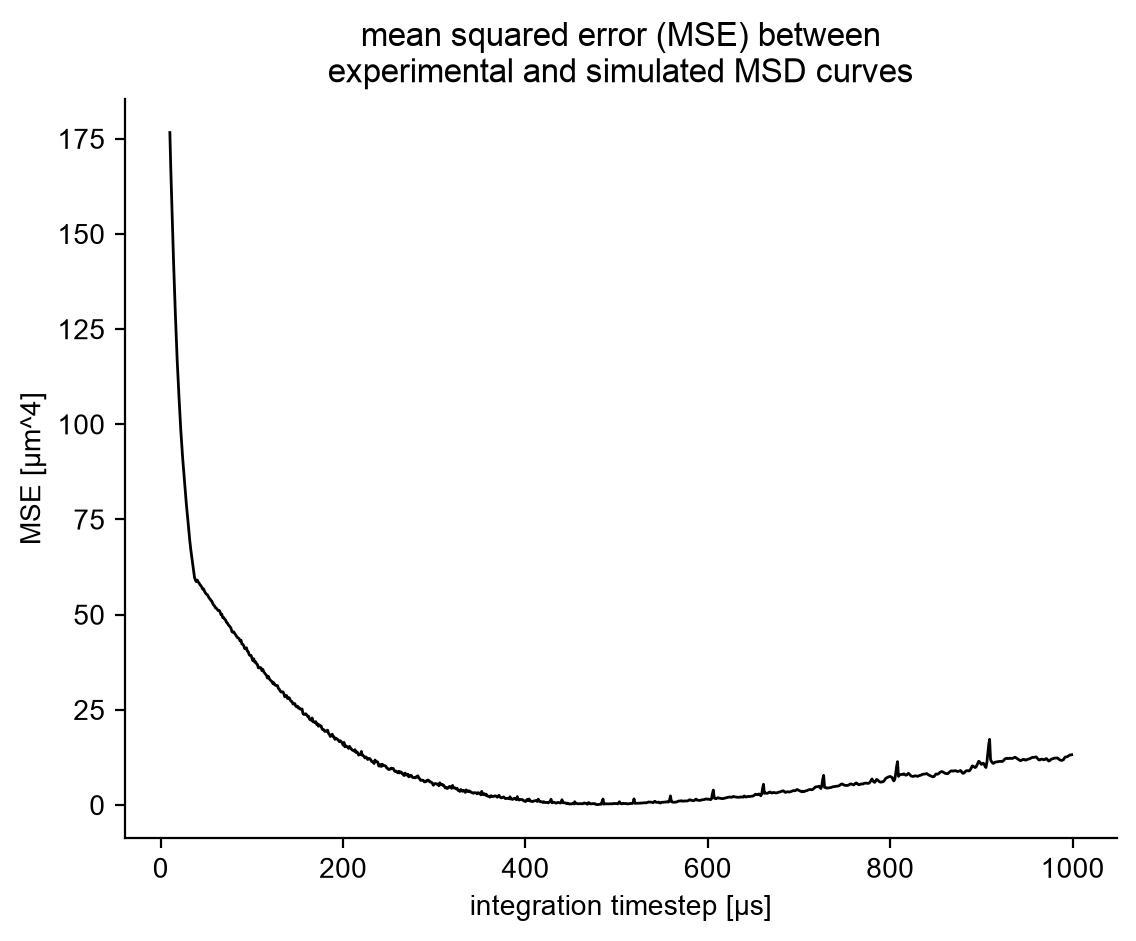

In [27]:
t_arr = np.arange(0.000010, 0.001000, 0.000001)
mse_arr = np.zeros(len(t_arr))
for i, t in enumerate(t_arr):
    mse_arr[i] = get_mse(monomer_size_um, t)
fig, ax = plt.subplots()
ax.plot(t_arr*1e6, mse_arr*1e3, linewidth=1, color='black');
ax.set_xlabel('integration timestep [\u03BCs]');
ax.set_ylabel('MSE [\u03BCm^4]');
ax.set_title('mean squared error (MSE) between\nexperimental and simulated MSD curves');
ax.spines[['top','right']].set_visible(False)


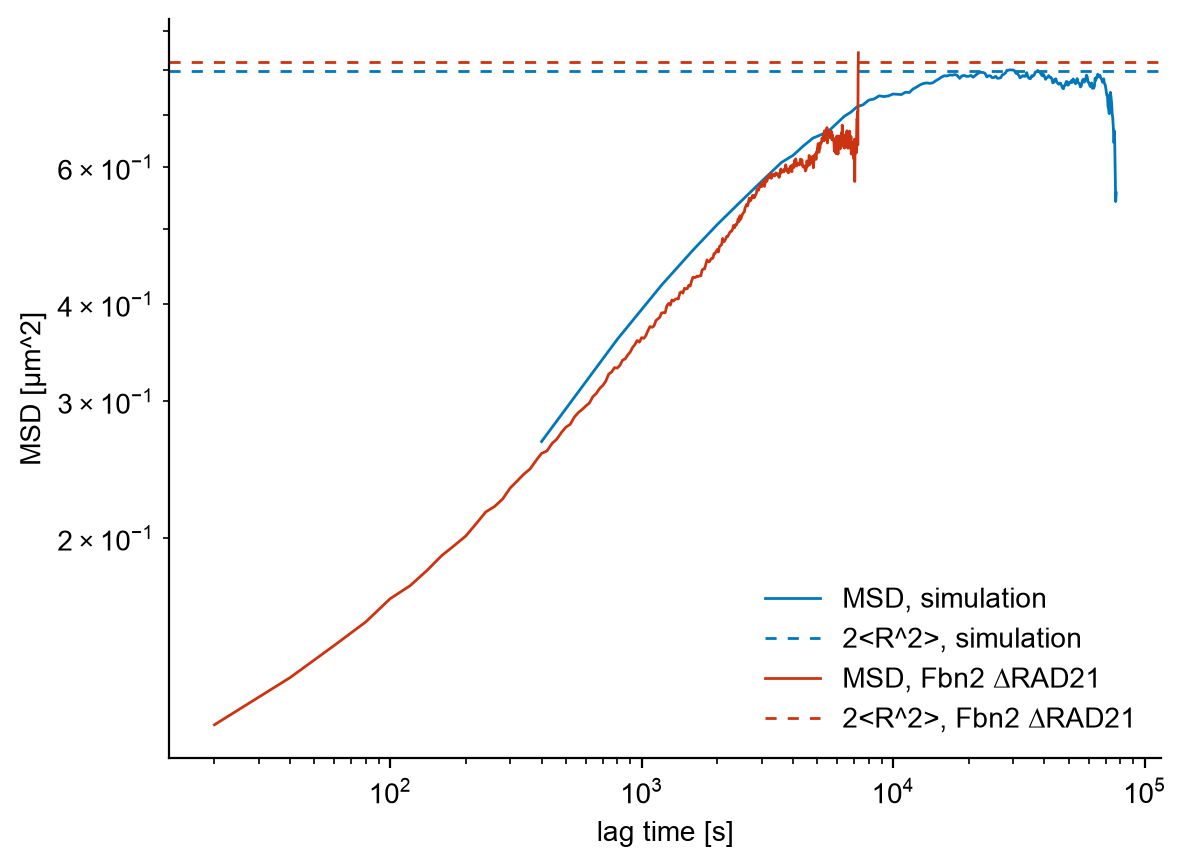

In [28]:
# fitting

sim_timestep_duration = 400e-6

delta_t_sim = msd_df['delta_t'] * sim_timestep_duration
msd_sim = msd_df['msd'] * (monomer_size_um)**2
convergent_value_sim = convergent_value * (monomer_size_um)**2

fig, ax = plt.subplots()
ax.plot(delta_t_sim, msd_sim, color='#0077bb', linewidth=1)
ax.axhline(y=convergent_value_sim, linestyle='--', color='#0077bb', linewidth=1, zorder=-1, dashes=[4,4]);
ax.plot(delta_t_Fbn2, msd_Fbn2, color='#cc3311', linewidth=1)
ax.axhline(y=0.82, linestyle='--', color='#cc3311', linewidth=1, zorder=-1, dashes=[4,4])
ax.legend(['MSD, simulation','2<R^2>, simulation','MSD, Fbn2 ∆RAD21','2<R^2>, Fbn2 ∆RAD21'], frameon=False)
ax.set_xlabel('lag time [s]');
ax.set_ylabel('MSD [\u03BCm^2]')
#ax.set_title('Comparison of simulated and experimental MSD curves\n'+f'monomer size {monomer_size_um*1e3:.0f} nm, integration timestep {sim_timestep_duration*1e6:.0f} \u03BCs', pad=8, fontsize=7);
ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xlim(1e2,1e4);
#ax.set_ylim(1e-1,1);
ax.spines[['top','right']].set_visible(False)
